In [59]:
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [60]:
#Downloaded nltk resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:/Users/modin/AppData/Roaming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:/Users/modin/AppData/Roaming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:/Users/modin/AppData/Roaming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:/Users/modin/AppData/Roaming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [62]:
data = {
    'text': [
        "I love this movie",
        "Amazing product quality",
        "Excellent experience",
        "Very happy with service",
        "Fantastic performance",
        "Great customer support",
        "I really enjoyed it",
        "Superb design",
        "Highly recommended product",
        "Best purchase ever",
        "Wonderful experience",
        "Brilliant work",
        "Perfect choice",
        "I am very satisfied",
        "Outstanding quality",
        "Incredible service",
        "Top notch product",
        "Really good experience",
        "I love it so much",
        "Very impressive work",
        "Excellent support team",
        "Happy with purchase",
        "Great value for money",
        "Very useful product",
        "Amazing experience",
        "Loved the service",
        "Fantastic quality",
        "Excellent product",
        "Very good experience",
        "Super happy customer",
        "Perfect product",
        "Really amazing work",
        "Highly satisfied",
        "Brilliant product",
        "Awesome experience",
        "Good quality service",
        "I am impressed",
        "Best experience ever",
        "Very good support",
        "Excellent value",
        "Loved it",
        "Extremely happy",
        "Fantastic service",
        "Superb experience",
        "Great product",
        "Very nice quality",
        "I strongly recommend",
        "Wonderful product",
        "Excellent work",
        "Very satisfied customer",
        "Amazing service",
        "Perfect experience",
        "Great performance",
        "Loved everything",
        "Best quality ever",
        "Very positive experience",
        "Outstanding service",
        "Excellent results",
        "Super happy",
        "Wonderful support",
        "I hate this movie",
        "Terrible product quality",
        "Worst experience ever",
        "Very bad service",
        "Awful performance",
        "Poor customer support",
        "I did not enjoy it",
        "Ugly design",
        "Not recommended at all",
        "Worst purchase ever",
        "Horrible experience",
        "Very disappointed",
        "Bad quality product",
        "I am not satisfied",
        "Terrible quality",
        "Worst service ever",
        "Disgusting product",
        "Really bad experience",
        "I hate it so much",
        "Very poor work",
        "Bad support team",
        "Unhappy with purchase",
        "Waste of money",
        "Useless product",
        "Horrible experience",
        "Did not like service",
        "Very bad quality",
        "Worst product",
        "Bad experience",
        "Not happy customer",
        "Poor product",
        "Really awful work",
        "Highly disappointed",
        "Pathetic product",
        "Terrible experience",
        "Bad quality service",
        "I am upset",
        "Worst experience ever",
        "Very poor support",
        "No value at all",
        "Hated it",
        "Extremely bad",
        "Terrible service",
        "Worst experience",
        "Bad product",
        "Very cheap quality",
        "I do not recommend",
        "Horrible product",
        "Bad work",
        "Very dissatisfied customer",
        "Awful service",
        "Worst experience ever",
        "Bad performance",
        "Hated everything",
        "Worst quality ever",
        "Very negative experience",
        "Pathetic service",
        "Terrible results",
        "Very unhappy",
        "Horrible support"
    ],
    
    'sentiment': [
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0
    ]
}

df = pd.DataFrame(data)

print(df)

                         text  sentiment
0           I love this movie          1
1     Amazing product quality          1
2        Excellent experience          1
3     Very happy with service          1
4       Fantastic performance          1
..                        ...        ...
115  Very negative experience          0
116          Pathetic service          0
117          Terrible results          0
118              Very unhappy          0
119          Horrible support          0

[120 rows x 2 columns]


In [ ]:
#Tokenization + Stop-word Removal + Lemmatization
stop_words = set(stopwords.words('english'))

stop_words.remove('not')

lemmatizer = WordNetLemmatizer()

def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Tokenization
    words = word_tokenize(text)

    # Remove stop words and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(words)

In [64]:
df['clean_text'] = df['text'].apply(preprocess)

print(df[['text','clean_text']])

                         text               clean_text
0           I love this movie               love movie
1     Amazing product quality  amazing product quality
2        Excellent experience     excellent experience
3     Very happy with service            happy service
4       Fantastic performance    fantastic performance
..                        ...                      ...
115  Very negative experience      negative experience
116          Pathetic service         pathetic service
117          Terrible results          terrible result
118              Very unhappy                  unhappy
119          Horrible support         horrible support

[120 rows x 2 columns]


In [65]:
#Generate TF-IDF Features
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment']

In [66]:
print(vectorizer.get_feature_names_out())

['amazing' 'awesome' 'awful' 'bad' 'best' 'brilliant' 'cheap' 'choice'
 'customer' 'design' 'disappointed' 'disgusting' 'dissatisfied' 'enjoy'
 'enjoyed' 'ever' 'everything' 'excellent' 'experience' 'extremely'
 'fantastic' 'good' 'great' 'happy' 'hate' 'hated' 'highly' 'horrible'
 'impressed' 'impressive' 'incredible' 'like' 'love' 'loved' 'money'
 'movie' 'much' 'negative' 'nice' 'not' 'notch' 'outstanding' 'pathetic'
 'perfect' 'performance' 'poor' 'positive' 'product' 'purchase' 'quality'
 'really' 'recommend' 'recommended' 'result' 'satisfied' 'service'
 'strongly' 'super' 'superb' 'support' 'team' 'terrible' 'top' 'ugly'
 'unhappy' 'upset' 'useful' 'useless' 'value' 'waste' 'wonderful' 'work'
 'worst']


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

In [68]:
#Train Logistic Regression Model
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
#Make predictions
y_pred = model.predict(X_test)

In [70]:
#Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.74      0.85      0.79        20

    accuracy                           0.78        40
   macro avg       0.78      0.77      0.77        40
weighted avg       0.78      0.78      0.77        40



In [74]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[14  6]
 [ 3 17]]


In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [76]:
cm = confusion_matrix(y_test, y_pred)

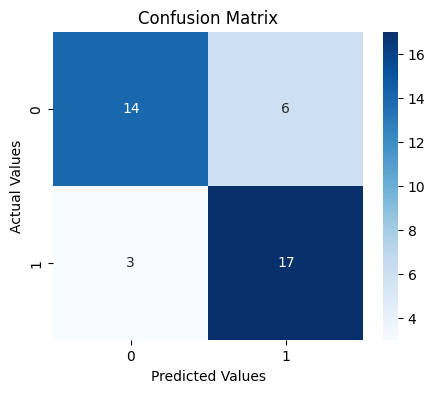

In [77]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")

plt.show()

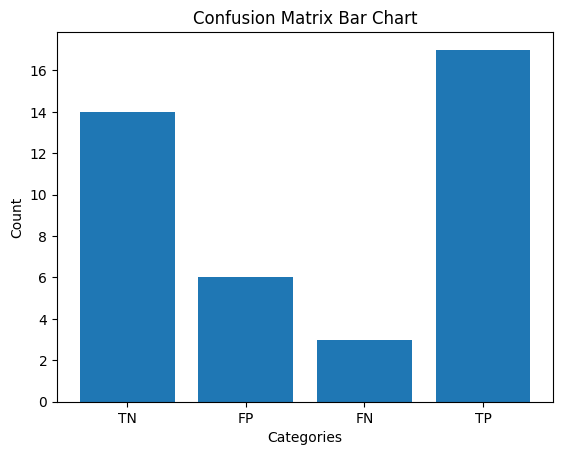

In [78]:
labels = ["TN", "FP", "FN", "TP"]
values = [14, 6, 3, 17]

plt.bar(labels, values)

plt.title("Confusion Matrix Bar Chart")
plt.xlabel("Categories")
plt.ylabel("Count")

plt.show()